## Define Task and Inspect the Data

In this assignment, we are given an xray image of a patient and we need to classify whether the patient has a pneumonia disease. There are 3 input data that is given, which is the dicom file containing the image of the xray with some other metadata. The second input is a csv file containing the label of the image and the bounding box of where the pneumonia is detected. The third input is a csv file that contains the mapping of the rsna to nih id  

TODO what is third csv

### Data Loading

In [1]:
from pathlib import Path
DATA_ROOT = Path("data/images")
LABEL_FILE = Path("assignment1_labels.csv")
MAPPING_FILE = Path("rsna_to_nih_mapping.csv")

In [2]:
dicom_files = sorted(DATA_ROOT.rglob("*.dcm"))
print("DICOM files found:", len(dicom_files))
print("Label file found:", LABEL_FILE.exists())

print("Mapping file found:", MAPPING_FILE.exists())
assert len(dicom_files) > 0, "No DICOM files were found."
assert LABEL_FILE.exists(), "The label file was not found."
assert MAPPING_FILE.exists(), "The mapping file was not found."

DICOM files found: 25684
Label file found: True
Mapping file found: True


### Inspect Data

In [3]:
import pydicom
import pandas as pd

metadata_list = []
for path in dicom_files: 
    ds = pydicom.dcmread(path)
    metadata_list.append({
        "File Path": str(path),
        "Patient ID": ds.PatientID,
        "SOP Instance UID": ds.SOPInstanceUID,
        "Study Instance UID": ds.StudyInstanceUID,
        "Study Date": ds.StudyDate,
        "Series Instance UID": ds.SeriesInstanceUID,
        "Modality": ds.Modality,
        "Body Part Examined": ds.BodyPartExamined if 'BodyPartExamined' in ds else None,
        "Manufacturer": ds.Manufacturer if 'Manufacturer' in ds else None,

        "Rows": ds.get("Rows", pd.NA),
        "Columns": ds.get("Columns", pd.NA),
        "Photometric Interpretation": ds.get("PhotometricInterpretation", pd.NA),
        "View Position": ds.get("ViewPosition", pd.NA)
    })

metadata_df = pd.DataFrame(metadata_list)
metadata_df.head()

,File Path,Patient ID,SOP Instance UID,Study Instance UID,Study Date,Series Instance UID,Modality,Body Part Examined,Manufacturer,Rows,Columns,Photometric Interpretation,View Position
0,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,4af96201-f655-4ee8-af0c-0cd3cbe64df7,1.2.276.0.7230010.3.1.4.8323329.10001.15178743...,1.2.276.0.7230010.3.1.2.8323329.10001.15178743...,19010101,1.2.276.0.7230010.3.1.3.8323329.10001.15178743...,CR,CHEST,None,1024,1024,MONOCHROME2,AP
1,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,ee9c1ee7-38c3-45f0-ac3b-5bdda1fc4223,1.2.276.0.7230010.3.1.4.8323329.10002.15178743...,1.2.276.0.7230010.3.1.2.8323329.10002.15178743...,19010101,1.2.276.0.7230010.3.1.3.8323329.10002.15178743...,CR,CHEST,None,1024,1024,MONOCHROME2,PA
2,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,90519cd3-09c1-4c20-92b7-f494a19f0ae0,1.2.276.0.7230010.3.1.4.8323329.10004.15178743...,1.2.276.0.7230010.3.1.2.8323329.10004.15178743...,19010101,1.2.276.0.7230010.3.1.3.8323329.10004.15178743...,CR,CHEST,None,1024,1024,MONOCHROME2,AP
3,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,4d839a29-e065-431c-8cdc-9277432c966f,1.2.276.0.7230010.3.1.4.8323329.10005.15178743...,1.2.276.0.7230010.3.1.2.8323329.10005.15178743...,19010101,1.2.276.0.7230010.3.1.3.8323329.10005.15178743...,CR,CHEST,None,1024,1024,MONOCHROME2,PA
4,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,75ed8091-a23e-4dba-84fa-014f5920e9a5,1.2.276.0.7230010.3.1.4.8323329.10006.15178743...,1.2.276.0.7230010.3.1.2.8323329.10006.15178743...,19010101,1.2.276.0.7230010.3.1.3.8323329.10006.15178743...,CR,CHEST,None,1024,1024,MONOCHROME2,PA


In [4]:
mapping_df = pd.read_csv(MAPPING_FILE, dtype=str)

# The mapping file's patientId matches the DICOM SOPInstanceUID.
# Use the mapped NIH patient ID to count distinct patients.
available_mapping = mapping_df[
    mapping_df["patientId"].isin(metadata_df["SOP Instance UID"])
]

n_instances = len(metadata_df)
n_rsna_image_ids = metadata_df["SOP Instance UID"].nunique()
n_patients = available_mapping["nih_patient_id"].nunique()
n_studies = metadata_df["Study Instance UID"].nunique()
n_series = metadata_df["Series Instance UID"].nunique()

print(f"Number of instances: {n_instances}")
print(f"Number of unique RSNA image IDs: {n_rsna_image_ids}")
print(f"Number of unique NIH patients: {n_patients}")
print(f"Number of studies: {n_studies}")
print(f"Number of series: {n_series}")

Number of instances: 25684
Number of unique RSNA image IDs: 25684
Number of unique NIH patients: 11171
Number of studies: 25684
Number of series: 25684


There are 11171 unique patients based on the rsna to nih mapping csv file so we need to consider this at splitting the data

In [12]:
available_mapping.head()

,patientId,nih_patient_id,nih_image_id
0,1.2.276.0.7230010.3.1.4.8323329.10001.15178743...,00011683,00011683_018.png
1,1.2.276.0.7230010.3.1.4.8323329.10002.15178743...,00002245,00002245_000.png
2,1.2.276.0.7230010.3.1.4.8323329.10004.15178743...,00030355,00030355_000.png
3,1.2.276.0.7230010.3.1.4.8323329.10005.15178743...,00014758,00014758_000.png
4,1.2.276.0.7230010.3.1.4.8323329.10006.15178743...,00004082,00004082_008.png


In [16]:
import pandas as pd

label_df = pd.read_csv(LABEL_FILE)

study_to_path = metadata_df.set_index("Study Instance UID")["File Path"]
label_df["File Path"] = label_df["StudyInstanceUID"].map(study_to_path)

study_id_to_nih_id = available_mapping.set_index("patientId")["nih_patient_id"]
label_df["nih_patient_id"] = label_df["SOPInstanceUID"].map(study_id_to_nih_id)

display(label_df.head())
display(mapping_df.head())

print("Labels without a DICOM file:", label_df["File Path"].isna().sum())

,patientId,x,y,width,height,Target,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,File Path,nih_patient_id
0,1.2.276.0.7230010.3.1.4.8323329.5872.151787431...,NaN,NaN,NaN,NaN,0,1.2.276.0.7230010.3.1.2.8323329.5872.151787431...,1.2.276.0.7230010.3.1.3.8323329.5872.151787431...,1.2.276.0.7230010.3.1.4.8323329.5872.151787431...,data/images/1.2.276.0.7230010.3.1.2.8323329.58...,00020276
1,1.2.276.0.7230010.3.1.4.8323329.15466.15178743...,NaN,NaN,NaN,NaN,0,1.2.276.0.7230010.3.1.2.8323329.15466.15178743...,1.2.276.0.7230010.3.1.3.8323329.15466.15178743...,1.2.276.0.7230010.3.1.4.8323329.15466.15178743...,data/images/1.2.276.0.7230010.3.1.2.8323329.15...,00003755
2,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...,564.0,356.0,274.0,496.0,1,1.2.276.0.7230010.3.1.2.8323329.10973.15178743...,1.2.276.0.7230010.3.1.3.8323329.10973.15178743...,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,00006774
3,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...,195.0,320.0,281.0,515.0,1,1.2.276.0.7230010.3.1.2.8323329.10973.15178743...,1.2.276.0.7230010.3.1.3.8323329.10973.15178743...,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,00006774
4,1.2.276.0.7230010.3.1.4.8323329.22658.15178744...,NaN,NaN,NaN,NaN,0,1.2.276.0.7230010.3.1.2.8323329.22658.15178744...,1.2.276.0.7230010.3.1.3.8323329.22658.15178744...,1.2.276.0.7230010.3.1.4.8323329.22658.15178744...,data/images/1.2.276.0.7230010.3.1.2.8323329.22...,00004413


,patientId,nih_patient_id,nih_image_id
0,1.2.276.0.7230010.3.1.4.8323329.10001.15178743...,00011683,00011683_018.png
1,1.2.276.0.7230010.3.1.4.8323329.10002.15178743...,00002245,00002245_000.png
2,1.2.276.0.7230010.3.1.4.8323329.10004.15178743...,00030355,00030355_000.png
3,1.2.276.0.7230010.3.1.4.8323329.10005.15178743...,00014758,00014758_000.png
4,1.2.276.0.7230010.3.1.4.8323329.10006.15178743...,00004082,00004082_008.png


Labels without a DICOM file: 0


In [6]:
# Class counts and proportion
pd.DataFrame({
    "Class Count": label_df['Target'].value_counts(),
    "Class Percentage": label_df['Target'].value_counts() / len(label_df),
})

,Class Count,Class Percentage
Target,,
0,20025,0.690779
1,8964,0.309221


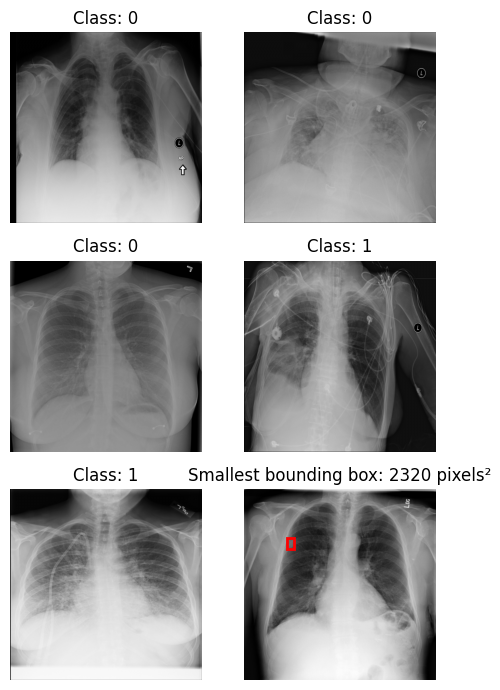

In [7]:
# Display at least six representative images: positive and negative examples, and the one with the smallest bounding box

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

positive_df = label_df[label_df["Target"] == 1].copy()
negative_df = label_df[label_df["Target"] == 0].copy()

# Locate the smallest positive bounding box
positive_df["Box Area"] = positive_df["width"] * positive_df["height"]
smallest_row = positive_df.loc[positive_df["Box Area"].idxmin()]
smallest_study = smallest_row["StudyInstanceUID"]

# Select three unique negatives and two other unique positives
negative_examples = (
    negative_df
    .drop_duplicates("StudyInstanceUID")
    .sample(3, random_state=42)
)

positive_examples = (
    positive_df[positive_df["StudyInstanceUID"] != smallest_study]
    .drop_duplicates("StudyInstanceUID")
    .sample(2, random_state=42)
)

displayed_dicom = pd.concat([
    negative_examples,
    positive_examples,
    smallest_row.to_frame().T
])

fig, axes = plt.subplots(3, 2, figsize=(5, 7))

for i, (_, row) in enumerate(displayed_dicom.iterrows()):
    ds = pydicom.dcmread(row["File Path"])
    image = ds.pixel_array

    ax = axes.flat[i]
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Class: {row['Target']}")
    ax.axis("off")

    # Highlight the smallest bounding box
    if i == 5:
        box = Rectangle(
            (float(row["x"]), float(row["y"])),
            float(row["width"]),
            float(row["height"]),
            edgecolor="red",
            facecolor="none",
            linewidth=2
        )
        ax.add_patch(box)
        ax.set_title(
            f"Smallest bounding box: {int(row['Box Area'])} pixels²"
        )

plt.tight_layout()
plt.show()

In [8]:
# Check image size, photometric interpretation and projection/view information when available
print("Image size counts:")
display(metadata_df.value_counts(["Rows", "Columns"], dropna=False).rename("Count").reset_index())

print("Photometric interpretation counts:")
display(metadata_df["Photometric Interpretation"].value_counts(dropna=False))

print("Projection/view counts:")
display(metadata_df["View Position"].value_counts(dropna=False)) # AP is Anterior Posterior / from the front

Image size counts:


,Rows,Columns,Count
0,1024,1024,25684


Photometric interpretation counts:


Photometric Interpretation
MONOCHROME2    25684
Name: count, dtype: int64

Projection/view counts:


View Position
PA    13979
AP    11705
Name: count, dtype: int64

## Create Splits

In [28]:
# train, val, and test split based on NIH data
from sklearn.model_selection import GroupShuffleSplit

split1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=67)
train_idx, temp_idx = next(split1.split(label_df, groups=label_df["nih_patient_id"]))

train_df = label_df.iloc[train_idx].reset_index(drop=True)
temp_df = label_df.iloc[temp_idx].reset_index(drop=True)

split2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=67)
val_idx, test_idx = next(split2.split(temp_df, groups=temp_df['nih_patient_id']))

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print(f"Train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

# positive class proportion
print("Train")
display(train_df['Target'].value_counts() / len(train_df['Target']))
print("Val")
display(val_df['Target'].value_counts() / len(val_df['Target']))
print("Test")
display(test_df['Target'].value_counts() / len(test_df['Target']))

# verify no overlap
train_patients = set(train_df['nih_patient_id'])
val_patients = set(val_df['nih_patient_id'])
test_patients = set(test_df['nih_patient_id'])

assert(len(train_patients & val_patients) == 0)
assert(len(train_patients & test_patients) == 0)
assert(len(test_patients & val_patients) == 0)

print("Train-Val overlap:", train_patients & val_patients)
print("Train-Test overlap:", train_patients & test_patients)
print("Val-Test overlap:", val_patients & test_patients)

Train: 23326, val: 2818, test: 2845
Train


Target
0    0.690003
1    0.309997
Name: count, dtype: float64

Val


Target
0    0.681689
1    0.318311
Name: count, dtype: float64

Test


Target
0    0.706151
1    0.293849
Name: count, dtype: float64

Train-Val overlap: set()
Train-Test overlap: set()
Val-Test overlap: set()


In multi site dataset, there might be a leakage where the model already learn the pattern from all of the site on the data thus it might overfit to test data and perform poorly when used on site/place outside the collected data or in real world application. To handle this, we also need to consider the site on to the splitting, such as by excluding the data from a certain site on the train data so the test data result can reduce this impact

## Preprocessing and Augmentation

In [57]:
# convert dicom to tensor
# we use dataset so the data will gradually loaded to the ram when needed
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

DEVICE = torch.device("cpu")
BATCH_SIZE = 16

class DICOM_dataset(Dataset):
    def __init__(self, df, image_col, label_col, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_col = image_col
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        path = self.df.loc[index, self.image_col]

        dcm = pydicom.dcmread(path)
        image = dcm.pixel_array.astype(np.float32)

        # rescale
        slope = float(getattr(dcm, "RescaleSlope", 1.0))
        intercept = float(getattr(dcm, "RescaleIntercept", 0.0))
        image = image * slope + intercept

        # normalize
        min_val = image.min()
        max_val = image.max()
        image = (image - min_val) / (max_val - min_val)

        image = torch.from_numpy(image).float().unsqueeze(0)

        if self.transform:
            image = self.transform(image)

        label = self.df.loc[index, self.label_col]
        label = torch.tensor(label, dtype=torch.float32)

        return image, label


In [58]:
# training only augmentation
import torchvision.transforms as T

train_transform = T.Compose([
    T.RandomRotation(degrees=7),

    T.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05)
    ),

    T.RandomApply([
        T.ColorJitter(
            brightness=0.1,
            contrast=0.1
        )
    ], p=0.5),
])

In [68]:
train_dataset = DICOM_dataset(train_df, "File Path", "Target", transform=train_transform)
val_dataset = DICOM_dataset(val_df, "File Path", "Target")
test_dataset = DICOM_dataset(test_df, "File Path", "Target")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

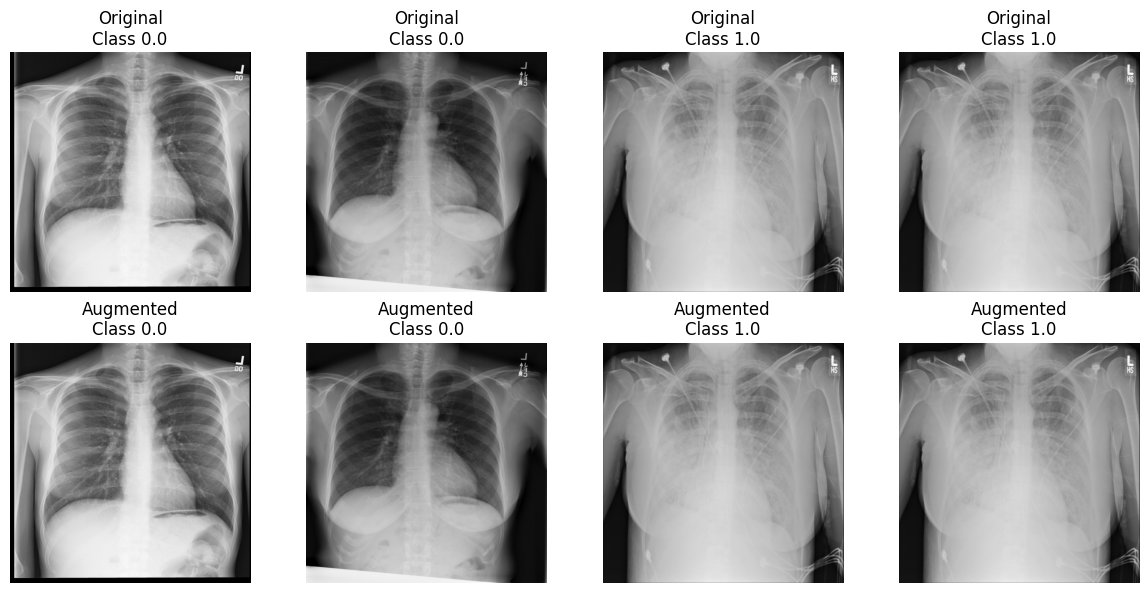

In [67]:
# example of train data with and without transform

train_dataset_transform = DICOM_dataset(train_df, "File Path", "Target")
train_transform_loader = DataLoader(
    train_dataset_transform,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

train_dataset_no_transform = DICOM_dataset(train_df, "File Path", "Target")
train_no_transform_loader = DataLoader(
    train_dataset_no_transform,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

images_no_transform, labels_no_transform = next(iter(train_no_transform_loader))
images_transform, labels_transform = next(iter(train_transform_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    # Original
    axes[0, i].imshow(
        images_no_transform[i].squeeze().cpu().numpy(),
        cmap="gray"
    )
    axes[0, i].set_title(f"Original\nClass {labels_no_transform[i].item()}")
    axes[0, i].axis("off")

    # Augmented
    axes[1, i].imshow(
        images_transform[i].squeeze().cpu().numpy(),
        cmap="gray"
    )
    axes[1, i].set_title(f"Augmented\nClass {labels_transform[i].item()}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()